### Astrostatistic Lecture 18

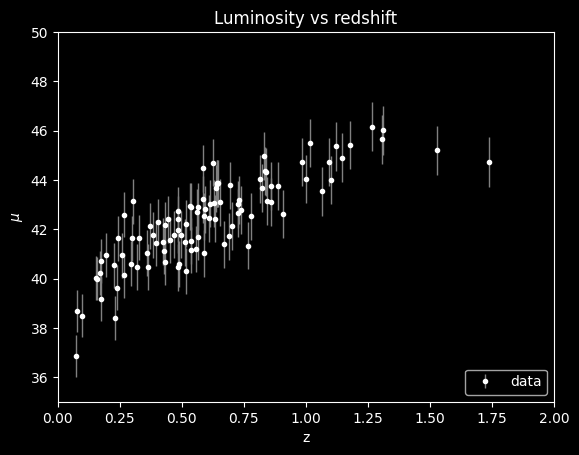

In [2]:
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
import numpy as np
from tqdm import tqdm
from scipy import stats
plt.rcParams['figure.facecolor'] = 'black' #custom plot stuff
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'white'         
plt.rcParams['axes.labelcolor'] = 'white'  
plt.rcParams['text.color'] = 'white'  
plt.rcParams['xtick.color'] = 'white'           
plt.rcParams['ytick.color'] = 'white'

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.', ecolor='gray', lw=1,label='data', color='white')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Luminosity vs redshift")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

best-fit theta = -0.04862355294816783


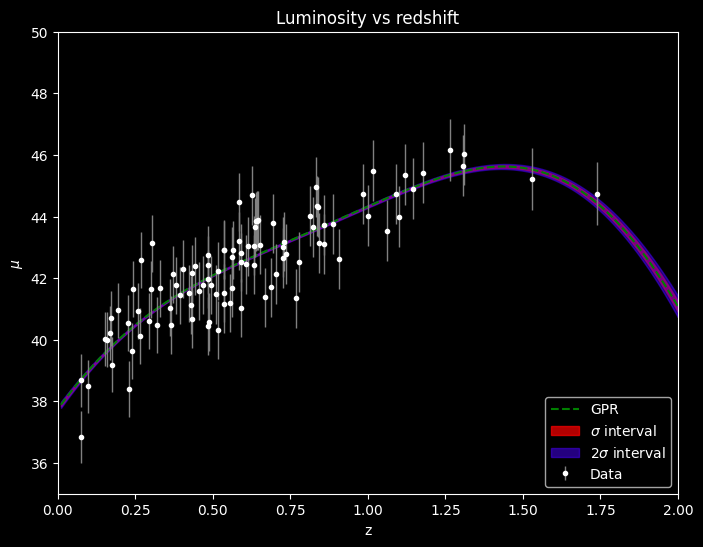

In [4]:
#try to fit the data with GPR
#we make the function pass into the data points
x = z_sample
x_test = np.linspace(0.01, 2, 10000)
y=np.random.normal(mu_sample, 0.1)

kernel = kernels.RBF(1, (0.01, 2.0))
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1**2, random_state=0)

gp.fit(x[:, None], y)
predic, predic_err = gp.predict(x_test[:, None], 
                         return_std=True)

print("best-fit theta =", gp.kernel_.theta[0])

plt.figure(figsize=(8, 6))
plt.plot(x_test, predic, linestyle='dashed', color='green', label='GPR')
plt.fill_between(x_test, predic - predic_err, predic + predic_err, 
                color="#FF0000FF", alpha=0.7, label=r'$\sigma$ interval')
plt.fill_between(x_test, predic - 2 * predic_err, predic + 2 * predic_err, 
                color="#4800FF", alpha=0.5, label=r'2$\sigma$ interval')
plt.errorbar(z_sample, mu_sample , dmu, fmt='.', ms=6, ecolor='gray', lw=1, label='Data', color='white')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Luminosity vs redshift")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

/home/ricca/astrostat/astrostatistics_bicocca_2026/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/ricca/astrostat/astrostatistics_bicocca_2026/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/ricca/astrostat/astrostatistics_bicocca_2026/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better valu

best-fit theta = 0.01


ValueError: x and y must have same first dimension, but have shapes (300,) and (1800,)

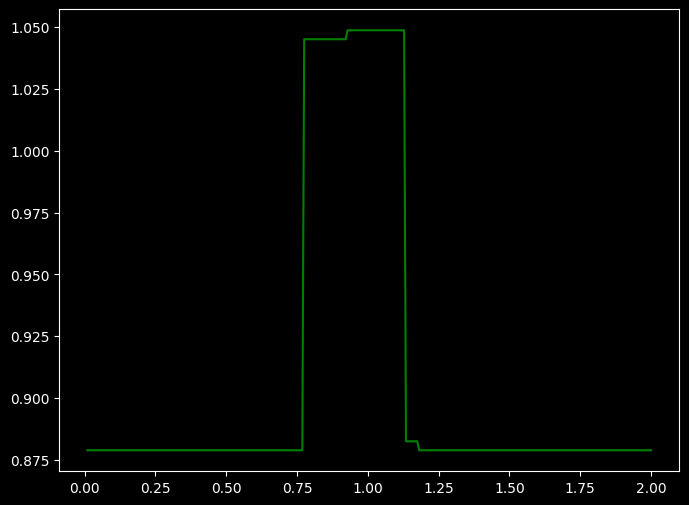

In [7]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
# now we need to do a cross validation on the GPR lengthscale

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores=[]
t_scores=[]
lengthscale = np.linspace(0.01, 2.0, 300)

for l in lengthscale:
    fold_errors = []
    t_err = []
    for train_idx, test_idx in kf.split(x):
        X_train, X_test = x[train_idx], x[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        kernel=kernels.RBF(l, (0.01, 2.0))
        gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1**2, random_state=0)
        gp.fit(X_train[:, None], y_train)
        y_pred = gp.predict(X_test[:, None])
        error = mean_squared_error(y_test, y_pred)
        fold_errors.append(error)
        train_error = mean_squared_error(y_train, gp.predict(X_train[:, None]))
        t_scores.append(train_error)
    scores.append(np.mean(fold_errors))
    t_scores.append(np.mean(train_error))
best_l = lengthscale[np.argmin(scores)]

print("best-fit theta =", best_l)

plt.figure(figsize=(8, 6))
plt.plot(lengthscale, scores, color='green', label='CV error')
plt.plot(lengthscale, t_scores, color='red', label='train error')
plt.xlabel("lengthscale")
plt.ylabel("CV error")
plt.legend(loc='upper right')
plt.yscale('log')
plt.show()
